### Reading

In [122]:
import pandas as pd
import numpy as np
import re
import ast
from pathlib import Path
import os

In [123]:
df = pd.read_csv(r"D:\99_acres_ml_project\data\raw.csv")

In [124]:
df.sample(3)

,property_name,link,society,price,rate,areaWithType,bedRoom,bathroom,balcony,additionalRoom,...,agePossession,nearbyLocations,description,furnishDetails,features,rating,property_id,property_type,area,noOfFloor
1884,3 BHK Flat in Sector 109 Gurgaon,https://www.99acres.com/3-bhk-bedroom-apartmen...,ATS Tourmaline3.9 ★,2.1 Crore,"₹ 8,123/sq.ft.",Super Built up area 2585(240.15 sq.m.)Built Up...,3 Bedrooms,4 Bathrooms,3+ Balconies,Servant Room,...,1 to 5 Year Old,"['Dwarka Sector 21 Metro Station', 'NeoSquare ...",Check out this 3 bhk flat for sale in ats tour...,"['3 Wardrobe', '7 Fan', '1 Exhaust Fan', '3 Ge...","['Water purifier', 'Security / Fire Alarm', 'P...","['Green Area4.5 out of 5', 'Construction4.5 ou...",A64232832,flat,NaN,NaN
1509,3 BHK Flat in Sector 56 Gurgaon,https://www.99acres.com/3-bhk-bedroom-apartmen...,Professors Enclave CGHS,1.54 Crore,"₹ 8,324/sq.ft.",Super Built up area 2000(185.81 sq.m.)Built Up...,3 Bedrooms,3 Bathrooms,2 Balconies,"Pooja Room,Servant Room",...,10+ Year Old,"['Sector metro station', 'Sector metro station...",This 3 bhk apartment is available for sale in ...,"['5 Fan', '1 Exhaust Fan', '3 Geyser', '12 Lig...","['Feng Shui / Vaastu Compliant', 'Lift(s)', 'H...","['Environment4 out of 5', 'Lifestyle5 out of 5...",U69431586,flat,NaN,NaN
2389,2 BHK Flat in Sector 79 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,"Godrej 101, Sector 79",1.25 Crore,"₹ 9,038/sq.ft.",Built Up area: 1383 (128.48 sq.m.),2 Bedrooms,2 Bathrooms,3 Balconies,NaN,...,undefined,"['Petrol Pump', 'Petrol Pump Indian Oil', 'Pet...",Best in class property available at sector 79 ...,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'N...",NaN,"['Environment4 out of 5', 'Lifestyle3 out of 5...",M69336192,flat,NaN,NaN


In [125]:
df.columns

Index(['property_name', 'link', 'society', 'price', 'rate', 'areaWithType',
       'bedRoom', 'bathroom', 'balcony', 'additionalRoom', 'address',
       'floorNum', 'facing', 'agePossession', 'nearbyLocations', 'description',
       'furnishDetails', 'features', 'rating', 'property_id', 'property_type',
       'area', 'noOfFloor'],
      dtype='object')

### Clean Price Column

In [126]:
df['price']

0           45 Lac
1           50 Lac
2           40 Lac
3       1.47 Crore
4           70 Lac
           ...    
4056     5.5 Crore
4057    4.25 Crore
4058     4.5 Crore
4059    3.25 Crore
4060     3.6 Crore
Name: price, Length: 4061, dtype: object

In [127]:
def clean_price(price_str):
    """Convert price string to numeric value in lakhs"""
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str).lower().strip()
    
    # Extract numeric value
    if 'cr' in price_str:
        num = float(re.findall(r'[\d.]+', price_str)[0])
        return num * 100  # Convert crore to lakh
    elif 'lac' in price_str:
        num = float(re.findall(r'[\d.]+', price_str)[0])
        return num
    else:
        # Try to extract any number
        numbers = re.findall(r'[\d.]+', price_str)
        if numbers:
            return float(numbers[0])
    return np.nan

In [128]:
df['price'] = df['price'].apply(clean_price)

### Clean Area Column

In [129]:
def clean_area(area_str, area_type='Super Built up area'):
    """Extract area in sq ft"""
    if pd.isna(area_str):
        return np.nan
    
    area_str = str(area_str).lower()
    
    # Extract square feet value
    sqft_match = re.search(r'(\d+(?:\.\d+)?)\s*(?:sq\.?\s*ft\.?|sqft)', area_str)
    if sqft_match:
        return float(sqft_match.group(1))
    
    # Extract square meter and convert
    sqm_match = re.search(r'(\d+(?:\.\d+)?)\s*(?:sq\.?\s*m\.?|sqm)', area_str)
    if sqm_match:
        return float(sqm_match.group(1)) * 10.764
    
    return np.nan

In [130]:
df['area_sqft'] = df['areaWithType'].apply(lambda x: clean_area(x))

### Clean Rate Column

In [131]:
def clean_rate(rate_str):
    """Extract rate per sq ft"""
    if pd.isna(rate_str):
        return np.nan
    
    rate_str = str(rate_str).lower()
    match = re.search(r'[\d,]+(?:\.\d+)?', rate_str.replace(',', ''))
    if match:
        return float(match.group())
    return np.nan

In [132]:
df['rate_per_sqft'] = df['rate'].apply(clean_rate)

### Extract Numeric Values from Text Columns

In [133]:
# Extract floor number
def extract_floor_num(floor_str):
    if pd.isna(floor_str):
        return np.nan
    floor_str = str(floor_str).lower()
    match = re.search(r'(\d+)(?:st|nd|rd|th)?\s*floor', floor_str)
    if match:
        return int(match.group(1))
    return np.nan

df['floor_number'] = df['floorNum'].apply(extract_floor_num)

# Extract age of property in years
def extract_age(age_str):
    if pd.isna(age_str):
        return np.nan
    age_str = str(age_str).lower()
    match = re.search(r'(\d+(?:\.\d+)?)\s*(?:year|yr)', age_str)
    if match:
        return float(match.group(1))
    return np.nan

df['property_age'] = df['agePossession'].apply(extract_age)

# Extract number of floors in building
def extract_total_floors(floor_str):
    if pd.isna(floor_str):
        return np.nan
    floor_str = str(floor_str).lower()
    match = re.search(r'out of (\d+)', floor_str)
    if match:
        return int(match.group(1))
    return np.nan

df['total_floors'] = df['floorNum'].apply(extract_total_floors)

### Handle Bedroom, Bathroom, Balcony

In [134]:
# Convert bedroom to numeric
df['bedroom_num'] = df['bedRoom'].str.extract(r'(\d+)').astype(float)

# Convert bathroom to numeric
df['bathroom_num'] = df['bathroom'].str.extract(r'(\d+)').astype(float)

# Convert balcony to numeric
df['balcony_num'] = df['balcony'].str.extract(r'(\d+)').astype(float)

### Process Features and Amenities

In [135]:
# Count number of features/amenities
def count_features(feature_list):
    if pd.isna(feature_list):
        return 0
    if isinstance(feature_list, list):
        return len(feature_list)
    return 0

df['feature_count'] = df['features'].apply(count_features)
df['furnish_count'] = df['furnishDetails'].apply(count_features)

# Extract safety, lifestyle, etc. ratings
def extract_rating(rating_list, category):
    """Extract specific rating from rating list"""
    if pd.isna(rating_list) or not isinstance(rating_list, list):
        return np.nan
    
    for item in rating_list:
        if category.lower() in item.lower():
            match = re.search(r'(\d+(?:\.\d+)?)\s*out of 5', item)
            if match:
                return float(match.group(1))
    return np.nan

df['safety_rating'] = df['rating'].apply(lambda x: extract_rating(x, 'safety'))
df['lifestyle_rating'] = df['rating'].apply(lambda x: extract_rating(x, 'lifestyle'))
df['green_area_rating'] = df['rating'].apply(lambda x: extract_rating(x, 'green'))
df['amenities_rating'] = df['rating'].apply(lambda x: extract_rating(x, 'amenities'))

### Create Additional Features

In [136]:
# Price per square foot (validation)
df['calculated_rate'] = (df['price'] * 100000) / df['area_sqft']

# Property value indicators
df['is_high_value'] = (df['price'] > df['price'].median()).astype(int)

# Location features
df['has_nearby_hospital'] = df['nearbyLocations'].apply(
    lambda x: 1 if pd.notna(x) and isinstance(x, list) and 
    any('hospital' in str(loc).lower() for loc in x) else 0
)

df['has_nearby_mall'] = df['nearbyLocations'].apply(
    lambda x: 1 if pd.notna(x) and isinstance(x, list) and 
    any('mall' in str(loc).lower() for loc in x) else 0
)

df['has_nearby_metro'] = df['nearbyLocations'].apply(
    lambda x: 1 if pd.notna(x) and isinstance(x, list) and 
    any('metro' in str(loc).lower() for loc in x) else 0
)

In [137]:
df.to_csv("raw_experiment_data.csv", index=False)

In [138]:
df.sample(3)

,property_name,link,society,price,rate,areaWithType,bedRoom,bathroom,balcony,additionalRoom,...,furnish_count,safety_rating,lifestyle_rating,green_area_rating,amenities_rating,calculated_rate,is_high_value,has_nearby_hospital,has_nearby_mall,has_nearby_metro
153,3 BHK Flat in Garauli Kalan,https://www.99acres.com/3-bhk-bedroom-apartmen...,ashiyara 2,45.0,"₹ 4,500/sq.ft.",Super Built up area 1000(92.9 sq.m.),3 Bedrooms,3 Bathrooms,2 Balconies,NaN,...,0,NaN,NaN,NaN,NaN,4500.109803,0,0,0,0
2811,2 BHK Flat in New Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,takshila heights sector 37 c,67.0,"₹ 5,583/sq.ft.",Super Built up area 1200(111.48 sq.m.),2 Bedrooms,2 Bathrooms,2 Balconies,NaN,...,0,NaN,NaN,NaN,NaN,5583.469570,0,0,0,0
2801,2 BHK Flat in Sector 104 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Godrej Summit3.7 ★,110.0,"₹ 8,669/sq.ft.",Super Built up area 1269(117.89 sq.m.),2 Bedrooms,2 Bathrooms,3 Balconies,Others,...,0,NaN,NaN,NaN,NaN,8668.461574,0,0,0,0


### Data Cleaning & Transformation

In [139]:
drop_cols = [
    "property_name", "link", "property_id",
    "rate", "calculated_rate",
    "areaWithType", "description", "features", "furnishDetails",
    "bedRoom", "bathroom", "balcony"
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')

In [140]:
df = df.dropna(subset=["price"])

In [141]:
df.sample(3)

,society,price,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,rating,property_type,...,feature_count,furnish_count,safety_rating,lifestyle_rating,green_area_rating,amenities_rating,is_high_value,has_nearby_hospital,has_nearby_mall,has_nearby_metro
3810,Vipul Tatvam Villa,725.0,"Pooja Room,Study Room,Servant Room,Store Room","Sector 48 Gurgaon, Gurgaon, Haryana",NaN,NaN,1 to 5 Year Old,"['Athena', 'Star Mall', 'The Sixth Element Sch...","['Environment4 out of 5', 'Lifestyle4 out of 5...",house,...,0,0,NaN,NaN,NaN,NaN,1,0,0,0
1195,Bestech Park View Grand Spa4.3 ★,222.0,Servant Room,"Sector-81, Sector 81 Gurgaon, Gurgaon, Haryana",15th of 19 Floors,South-East,1 to 5 Year Old,"['Sapphire 83 Mall', 'NH-8, IMT Manesar', 'Dwa...","['Green Area5 out of 5', 'Construction5 out of...",flat,...,0,0,NaN,NaN,NaN,NaN,1,0,0,0
859,Mahindra Aura4.2 ★,140.0,NaN,"110a, Sector 110 A Gurgaon, Gurgaon, Haryana",10th of 14 Floors,North,1 to 5 Year Old,"['Global Foyer Mall, Palam Vihar', 'Dwarka Ex...","['Green Area5 out of 5', 'Construction4 out of...",flat,...,0,0,NaN,NaN,NaN,NaN,0,0,0,0


In [142]:
df.columns

Index(['society', 'price', 'additionalRoom', 'address', 'floorNum', 'facing',
       'agePossession', 'nearbyLocations', 'rating', 'property_type', 'area',
       'noOfFloor', 'area_sqft', 'rate_per_sqft', 'floor_number',
       'property_age', 'total_floors', 'bedroom_num', 'bathroom_num',
       'balcony_num', 'feature_count', 'furnish_count', 'safety_rating',
       'lifestyle_rating', 'green_area_rating', 'amenities_rating',
       'is_high_value', 'has_nearby_hospital', 'has_nearby_mall',
       'has_nearby_metro'],
      dtype='object')

In [143]:
# Minimal columns for model training
minimal_columns = [
    # Core features
    'price',              # Target variable
    'area_sqft',          # Most important feature for price
    'bedroom_num',        # Number of bedrooms
    'bathroom_num',       # Number of bathrooms
    'balcony_num',        # Number of balconies
    
    # Location & property info
    'property_type',      # flat/house
    'facing',             # North-East, etc.
    'agePossession',      # Property age
    
    # Ratings (important for value)
    'safety_rating',
    'lifestyle_rating',
    'green_area_rating',
    'amenities_rating'
]

# Filter to only existing columns
minimal_columns = [col for col in minimal_columns if col in df.columns]

In [144]:
final_df = df[minimal_columns]

In [145]:
final_df

,price,area_sqft,bedroom_num,bathroom_num,balcony_num,property_type,facing,agePossession,safety_rating,lifestyle_rating,green_area_rating,amenities_rating
0,45.0,899.97804,2.0,2.0,1.0,flat,West,1 to 5 Year Old,NaN,NaN,NaN,NaN
1,50.0,650.03796,2.0,2.0,1.0,flat,West,10+ Year Old,NaN,NaN,NaN,NaN
2,40.0,595.03392,2.0,2.0,3.0,flat,NaN,0 to 1 Year Old,NaN,NaN,NaN,NaN
3,147.0,1199.97072,2.0,2.0,2.0,flat,NaN,Dec-23,NaN,NaN,NaN,NaN
4,70.0,1344.96180,2.0,2.0,3.0,flat,NaN,Under Construction,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
4056,550.0,1800.06372,4.0,4.0,3.0,house,North-East,5 to 10 Year Old,NaN,NaN,NaN,NaN
4057,425.0,1350.02088,3.0,2.0,3.0,house,North,10+ Year Old,NaN,NaN,NaN,NaN
4058,450.0,1350.02088,3.0,3.0,2.0,house,East,5 to 10 Year Old,NaN,NaN,NaN,NaN
4059,325.0,981.03096,3.0,3.0,3.0,house,West,10+ Year Old,NaN,NaN,NaN,NaN


In [146]:
rating_cols = ['safety_rating', 'lifestyle_rating', 'green_area_rating', 'amenities_rating']
df_cleaned = final_df.drop(columns=rating_cols)

In [147]:
df_cleaned['facing'] = df_cleaned['facing'].fillna(df_cleaned['facing'].mode()[0])

In [148]:
df_cleaned['agePossession'] = df_cleaned['agePossession'].fillna(df_cleaned['agePossession'].mode()[0])

In [149]:
# Create price_per_sqft feature
df_cleaned['price_per_sqft'] = df_cleaned['price'] / df_cleaned['area_sqft']

# Create total_rooms feature
df_cleaned['total_rooms'] = df_cleaned['bedroom_num'] + df_cleaned['bathroom_num']

# Create room_to_bath_ratio
df_cleaned['room_bath_ratio'] = df_cleaned['bedroom_num'] / df_cleaned['bathroom_num']

# Encode age categories numerically
age_mapping = {
    'Under Construction': 0,
    '0 to 1 Year Old': 1,
    '1 to 5 Year Old': 3,
    '5 to 10 Year Old': 7.5,
    '10+ Year Old': 15
}
df_cleaned['age_years'] = df_cleaned['agePossession'].map(age_mapping).fillna(5)  # Default 5 years for 'Dec-23' etc.

# Encode facing direction (simple encoding)
facing_mapping = {
    'North': 1,
    'North-East': 2,
    'East': 3,
    'South-East': 4,
    'South': 5,
    'South-West': 6,
    'West': 7,
    'North-West': 8
}
df_cleaned['facing_code'] = df_cleaned['facing'].map(facing_mapping).fillna(0)

# Encode property type
df_cleaned['property_type_code'] = (df_cleaned['property_type'] == 'house').astype(int)

In [150]:
cols = [
    'area_sqft',
    'bedroom_num',
    'bathroom_num', 
    'balcony_num',
    'property_type_code',
    'facing_code',
    'age_years',
    'price_per_sqft',
    'total_rooms',
    'room_bath_ratio',
    'price'
]

df_cleaned = df_cleaned[cols]

In [151]:
df_cleaned

,area_sqft,bedroom_num,bathroom_num,balcony_num,property_type_code,facing_code,age_years,price_per_sqft,total_rooms,room_bath_ratio,price
0,899.97804,2.0,2.0,1.0,0,7,3.0,0.050001,4.0,1.0,45.0
1,650.03796,2.0,2.0,1.0,0,7,15.0,0.076919,4.0,1.0,50.0
2,595.03392,2.0,2.0,3.0,0,3,1.0,0.067223,4.0,1.0,40.0
3,1199.97072,2.0,2.0,2.0,0,3,5.0,0.122503,4.0,1.0,147.0
4,1344.96180,2.0,2.0,3.0,0,3,0.0,0.052046,4.0,1.0,70.0
...,...,...,...,...,...,...,...,...,...,...,...
4056,1800.06372,4.0,4.0,3.0,1,2,7.5,0.305545,8.0,1.0,550.0
4057,1350.02088,3.0,2.0,3.0,1,1,15.0,0.314810,5.0,1.5,425.0
4058,1350.02088,3.0,3.0,2.0,1,3,7.5,0.333328,6.0,1.0,450.0
4059,981.03096,3.0,3.0,3.0,1,7,15.0,0.331284,6.0,1.0,325.0


In [152]:
X = df_cleaned[['area_sqft','bedroom_num','bathroom_num', 'balcony_num','property_type_code','facing_code','age_years','price_per_sqft','total_rooms','room_bath_ratio',]]
y = df_cleaned['price']

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X),columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

### Dagshub hosted MLFlow Experiment Tracking 

In [153]:
import os
import dagshub
import mlflow
import os
from dotenv import load_dotenv;load_dotenv()

True

In [154]:
# MLflow auth (already working)
os.environ["MLFLOW_TRACKING_USERNAME"] = os.getenv("MLFLOW_TRACKING_USERNAME")
os.environ["MLFLOW_TRACKING_PASSWORD"] = os.getenv("MLFLOW_TRACKING_PASSWORD")

mlflow.set_tracking_uri("https://dagshub.com/iamprashantjain/house_price_prediction.mlflow")

In [155]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Start MLflow run
mlflow.set_experiment("base model")

with mlflow.start_run():    
    # Train model
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Log to MLflow
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("R2", r2)
    
    # Log model
    mlflow.sklearn.log_model(model, "model")
    
    
    # Save and log the notebook
    import os
    notebook_path = r"D:\99_acres_ml_project\experiment\experiments.ipynb"
    os.system(f"jupyter nbconvert --to notebook --execute --inplace {notebook_path}")
    mlflow.log_artifact(notebook_path)
    
    print(f"\n Results:")
    print(f"   MAE: ₹{mae:.2f} Lakhs")
    print(f"   R2 Score: {r2:.3f}")
    print(f"\n Model logged to MLflow")

2026/04/06 17:11:35 INFO mlflow.tracking.fluent: Experiment with name 'base model' does not exist. Creating a new experiment.
2026/04/06 17:12:30 WARNING mlflow.models.model: Input example should be provided to infer model signature if the model signature is not provided when logging the model.



 Results:
   MAE: ₹8.33 Lakhs
   R2 Score: 0.972

 Model logged to MLflow


2026/04/06 17:14:14 INFO mlflow.tracking._tracking_service.client: 🏃 View run bright-bear-665 at: https://dagshub.com/iamprashantjain/house_price_prediction.mlflow/#/experiments/3/runs/ecfa89ec000e43f3a78faf6366f6a52e.
2026/04/06 17:14:14 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/iamprashantjain/house_price_prediction.mlflow/#/experiments/3.


### multiple algorithm

In [156]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import mlflow
import os

# Define algorithms dictionary (same pattern as your original)
algorithms = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'SVR': SVR()
}

# Start MLflow run
mlflow.set_experiment("multiple algorithm")

# Start parent run for all experiments
with mlflow.start_run(run_name="All Models Comparison") as parent_run:
    
    # Loop through algorithms (Child Runs)
    for algo_name, model in algorithms.items():
        with mlflow.start_run(run_name=algo_name, nested=True) as child_run:
            
            print(f"\n{'='*50}")
            print(f"Training: {algo_name}")
            print(f"{'='*50}")
            
            # Train model
            model.fit(X_train, y_train)
            
            # Predict
            y_pred = model.predict(X_test)
            
            # Calculate metrics
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)
            
            # Log parameters
            mlflow.log_param("model_type", algo_name)
            
            # Log algorithm-specific parameters
            if algo_name == 'RandomForest':
                mlflow.log_param("n_estimators", model.n_estimators)
            elif algo_name == 'GradientBoosting':
                mlflow.log_param("n_estimators", model.n_estimators)
                mlflow.log_param("learning_rate", model.learning_rate)
            elif algo_name == 'Ridge' or algo_name == 'Lasso':
                mlflow.log_param("alpha", model.alpha)
            elif algo_name == 'XGBoost':
                mlflow.log_param("n_estimators", model.n_estimators)
                mlflow.log_param("learning_rate", model.learning_rate)
            elif algo_name == 'KNN':
                mlflow.log_param("n_neighbors", model.n_neighbors)
            
            # Log metrics
            mlflow.log_metric("MAE", mae)
            mlflow.log_metric("R2", r2)
            
            # Log model
            mlflow.sklearn.log_model(model, "model")
            
            # Print results
            print(f"   MAE: ₹{mae:.2f} Lakhs")
            print(f"   R2 Score: {r2:.3f}")
            print(f"   Model logged to MLflow")

2026/04/06 17:14:15 INFO mlflow.tracking.fluent: Experiment with name 'multiple algorithm' does not exist. Creating a new experiment.



Training: RandomForest


2026/04/06 17:15:06 WARNING mlflow.models.model: Input example should be provided to infer model signature if the model signature is not provided when logging the model.


   MAE: ₹8.33 Lakhs
   R2 Score: 0.972
   Model logged to MLflow


2026/04/06 17:15:06 INFO mlflow.tracking._tracking_service.client: 🏃 View run RandomForest at: https://dagshub.com/iamprashantjain/house_price_prediction.mlflow/#/experiments/4/runs/6ff0abc2e2f14e23964a903c1066cc07.
2026/04/06 17:15:06 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/iamprashantjain/house_price_prediction.mlflow/#/experiments/4.


...

2026/04/06 17:18:20 INFO mlflow.tracking._tracking_service.client: 🏃 View run KNN at: https://dagshub.com/iamprashantjain/house_price_prediction.mlflow/#/experiments/4/runs/58e0c545d3cf4398ba4053ae66f53cf0.
2026/04/06 17:18:20 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/iamprashantjain/house_price_prediction.mlflow/#/experiments/4.



Training: SVR


2026/04/06 17:18:51 WARNING mlflow.models.model: Input example should be provided to infer model signature if the model signature is not provided when logging the model.


   MAE: ₹152.78 Lakhs
   R2 Score: -0.103
   Model logged to MLflow


2026/04/06 17:18:51 INFO mlflow.tracking._tracking_service.client: 🏃 View run SVR at: https://dagshub.com/iamprashantjain/house_price_prediction.mlflow/#/experiments/4/runs/d21f88d099204a059a7b3069bb6f7843.
2026/04/06 17:18:51 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/iamprashantjain/house_price_prediction.mlflow/#/experiments/4.
2026/04/06 17:18:52 INFO mlflow.tracking._tracking_service.client: 🏃 View run All Models Comparison at: https://dagshub.com/iamprashantjain/house_price_prediction.mlflow/#/experiments/4/runs/31d9a86a8ddd4e9c805779915c2374fa.
2026/04/06 17:18:52 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/iamprashantjain/house_price_prediction.mlflow/#/experiments/4.


### hyper parameter tuning

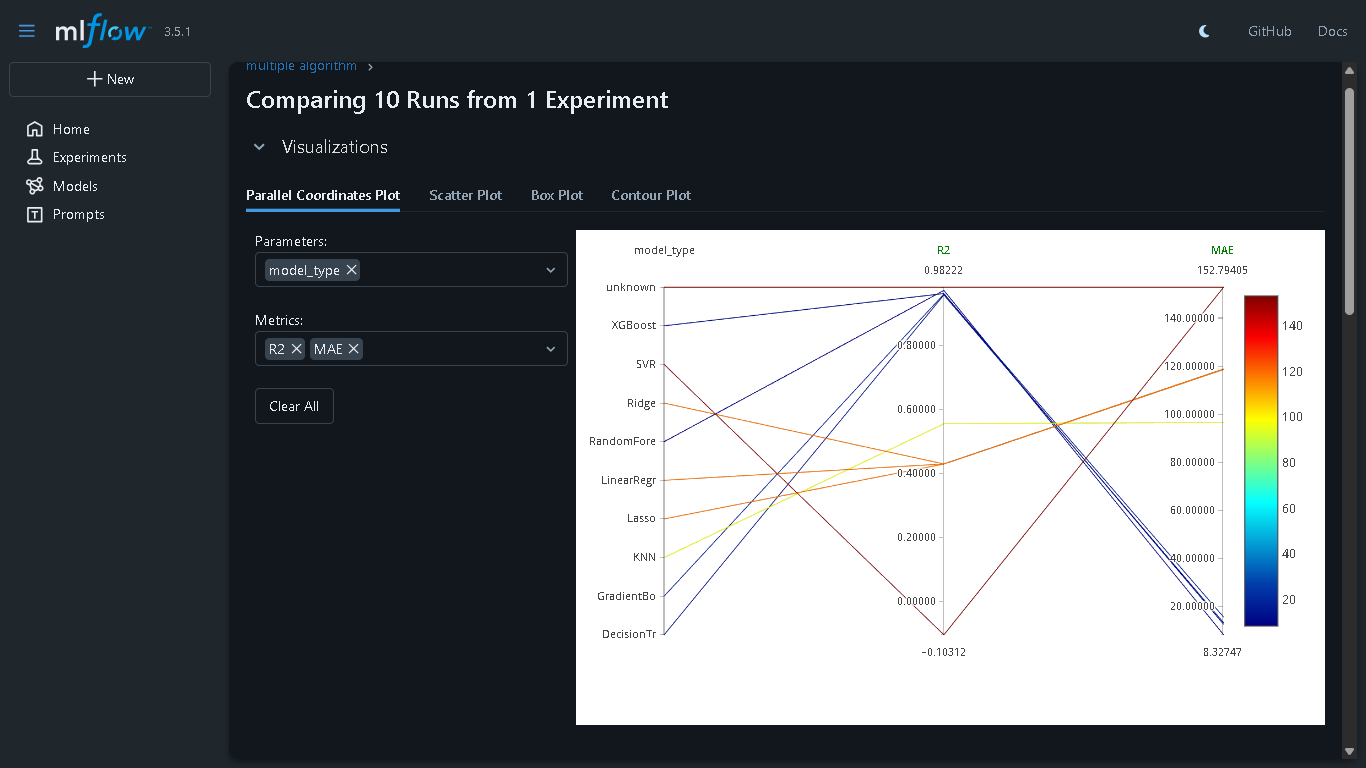

In [158]:
# random forest seems to be the best model highest r2 and lowest mae
# so we can do hyper parameter tuning on random forest

In [160]:
from sklearn.model_selection import GridSearchCV

mlflow.set_experiment("RandomForest_Hyperparameter_Tuning")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Start parent run
with mlflow.start_run(run_name="RF_Hyperparameter_Tuning") as parent_run:
    
    # Perform grid search with cross-validation
    rf = RandomForestRegressor(random_state=42, n_jobs=-1)
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    # Log each parameter combination as child runs
    for i, (params, mean_score, std_score) in enumerate(zip(
        grid_search.cv_results_['params'],
        grid_search.cv_results_['mean_test_score'],
        grid_search.cv_results_['std_test_score']
    )):
        with mlflow.start_run(run_name=f"RF_{params}", nested=True):
            # Train model with these parameters
            model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
            model.fit(X_train, y_train)
            
            # Evaluate on test set
            y_pred = model.predict(X_test)
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            
            # Log parameters and metrics
            mlflow.log_params(params)
            mlflow.log_metric("mean_cv_r2", mean_score)
            mlflow.log_metric("std_cv_r2", std_score)
            mlflow.log_metric("test_MAE", mae)
            mlflow.log_metric("test_RMSE", rmse)
            mlflow.log_metric("test_R2", r2)
    

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_
    
    # Log best parameters and score to parent run
    mlflow.log_params(best_params)
    mlflow.log_metric("best_cv_r2_score", best_score)
    
    # Evaluate best model on test set
    best_model = grid_search.best_estimator_
    y_pred_best = best_model.predict(X_test)
    best_mae = mean_absolute_error(y_test, y_pred_best)
    best_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
    best_r2 = r2_score(y_test, y_pred_best)
    
    # Log best model test metrics
    mlflow.log_metric("best_test_MAE", best_mae)
    mlflow.log_metric("best_test_RMSE", best_rmse)
    mlflow.log_metric("best_test_R2", best_r2)
    
    # Log feature importance of best model
    feature_importance = pd.DataFrame({
        'feature': features,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Save and log feature importance as artifact
    feature_importance.to_csv('feature_importance.csv', index=False)
    mlflow.log_artifact('feature_importance.csv')
    
    # Log the best model
    mlflow.sklearn.log_model(best_model, "best_random_forest_model")
    
    # Print results
    print("\n" + "="*60)
    print("HYPERPARAMETER TUNING COMPLETE")
    print("="*60)
    print(f"Best Parameters: {best_params}")
    print(f"Best Cross-Validation R2 Score: {best_score:.4f}")
    print(f"\nBest Model Performance on Test Set:")
    print(f"   MAE: ₹{best_mae:.2f} Lakhs")
    print(f"   RMSE: ₹{best_rmse:.2f} Lakhs")
    print(f"   R2 Score: {best_r2:.4f}")
    
    print("\nFeature Importance:")
    print(feature_importance.to_string(index=False))

Fitting 5 folds for each of 108 candidates, totalling 540 fits


2026/04/06 18:25:06 INFO mlflow.tracking._tracking_service.client: 🏃 View run RF_{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100} at: https://dagshub.com/iamprashantjain/house_price_prediction.mlflow/#/experiments/5/runs/c48660e67871412da2e1d3504b719f74.
2026/04/06 18:25:06 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/iamprashantjain/house_price_prediction.mlflow/#/experiments/5.
2026/04/06 18:25:07 INFO mlflow.tracking._tracking_service.client: 🏃 View run RF_Hyperparameter_Tuning at: https://dagshub.com/iamprashantjain/house_price_prediction.mlflow/#/experiments/5/runs/d3d4ceb45ae0477e886a88261ee787fb.
2026/04/06 18:25:07 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/iamprashantjain/house_price_prediction.mlflow/#/experiments/5.


NameError: name 'mean_squared_error' is not defined